## Titulo del Proyecto 
Análisis y Predicción de la Demanda por Especialidad Médica: Citas Futuras mediante Machine Learning y Time Series Forecasting

### Planteamiento
**Tipo de problema:** Time Series Forecasting

**Variable objetivo:** Número de citas

**Unidad temporal:** Día

**Segmentación:** Especialidad médica

**Frecuencia:** Diaria

**Tipo de serie:** Serie temporal de conteo discreto

**Modelo principal:** XGBoost

**Patrones a analizar:**

Seasonal Pattern

Increasing Linear Trend

Curvilinear Trend

Seasonal Pattern + Linear Growth



**Analisis****
Demanda por especialidad: Citas futuras segun especialidad

Tipo principal: Seasonal Pattern
Tipo de serie: Serie temporal de conteo discreto
Frecuencia: Diaria
Segmentación: Por especialidad médica
Tipos relacionados: Increasing Linear Trend, Curvilinear Trend y Seasonal Pattern plus Linear Growth, dependiendo del comportamiento observado en los datos.

### Cargamos las librerias

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.metrics import mean_squared_error

color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

### Cargar el DataSet

In [4]:
df = pd.read_csv(
    '/kaggle/input/datasets/joker1223335f/medical-appointments-no-show/Medical Appointments No-Show/medical-appointments-no-show-en.csv'
)

### Inspeccion Inicial :

In [5]:
df.head()
df.shape
df.info()
df.columns
df.isna().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49593 entries, 0 to 49592
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   specialty                42139 non-null  object 
 1   appointment_time         49593 non-null  object 
 2   gender                   49593 non-null  object 
 3   appointment_date         49593 non-null  object 
 4   no_show                  49593 non-null  object 
 5   no_show_reason           1737 non-null   object 
 6   disability               44456 non-null  object 
 7   date_of_birth            39272 non-null  object 
 8   entry_service_date       44438 non-null  object 
 9   city                     44412 non-null  object 
 10  icd                      10717 non-null  object 
 11  appointment_month        49593 non-null  object 
 12  appointment_year         49593 non-null  int64  
 13  appointment_shift        49593 non-null  object 
 14  age                   

np.int64(2921)

### Revisar las fechas 

In [7]:
df['appointment_date'] = pd.to_datetime(
    df['appointment_date'],
    format='%d/%m/%Y',
    errors='coerce'
)

#### Comprobamos rangos temporales 

In [8]:
print('Fecha mínima:', df['appointment_date'].min())
print('Fecha máxima:', df['appointment_date'].max())

Fecha mínima: 2016-06-20 00:00:00
Fecha máxima: 2022-02-25 00:00:00


Fechas invalidas 

In [9]:
print('Fechas inválidas:', df['appointment_date'].isna().sum())

Fechas inválidas: 0


Número de citas por día y por especialidad.

In [11]:
daily_specialty = (
    df.groupby(['appointment_date', 'specialty'])
      .size()
      .reset_index(name='appointments')
)

### Comprobamos el resultado

In [12]:
daily_specialty.head(20)

,appointment_date,specialty,appointments
0,2016-06-20,occupational therapy,4
1,2016-06-20,pedagogo,4
2,2016-06-20,physiotherapy,7
3,2016-06-20,psychotherapy,5
4,2016-06-20,speech therapy,10
5,2016-06-21,occupational therapy,3
6,2016-06-21,pedagogo,7
7,2016-06-21,physiotherapy,7
8,2016-06-21,psychotherapy,14
9,2016-06-21,speech therapy,9


Numero de especialidades:

In [13]:
print('Número de especialidades:', daily_specialty['specialty'].nunique())
daily_specialty['specialty'].value_counts()


Número de especialidades: 8


specialty
speech therapy          905
psychotherapy           897
physiotherapy           888
occupational therapy    828
pedagogo                324
enf                     292
assist                   71
sem especialidade         5
Name: count, dtype: int64

In [14]:
daily_specialty['specialty'].unique()

array(['occupational therapy', 'pedagogo', 'physiotherapy',
       'psychotherapy', 'speech therapy', 'enf', 'assist',
       'sem especialidade'], dtype=object)

### Elegimos una Especialidad 

In [16]:
specialty = 'physiotherapy'

### Centramos en Fecha y demanda: 

In [18]:
df_specialty = daily_specialty[
    daily_specialty['specialty'] == specialty
].copy()

In [20]:
df_specialty = df_specialty[
    ['appointment_date', 'appointments']
].copy()

In [21]:
df_specialty = df_specialty.set_index('appointment_date')
df_specialty = df_specialty.sort_index()

In [22]:
df_specialty.head()
df_specialty.tail()

,appointments
appointment_date,
2022-02-21,12
2022-02-22,8
2022-02-23,10
2022-02-24,11
2022-02-25,12


###  Convertir la frecuencia diaria

In [23]:
df_specialty = df_specialty.asfreq('D')

### Ahora rellenemos los dias sin citas 

In [25]:
df_specialty['appointments'] = (
    df_specialty['appointments'].fillna(0)
)

In [26]:
df_specialty.head(15)

,appointments
appointment_date,
2016-06-20,7.0
2016-06-21,7.0
2016-06-22,3.0
2016-06-23,0.0
2016-06-24,6.0
2016-06-25,0.0
2016-06-26,0.0
2016-06-27,4.0
2016-06-28,7.0


In [27]:
df_specialty['appointments'].describe()

count    2077.000000
mean        4.368801
std         6.274835
min         0.000000
25%         0.000000
50%         0.000000
75%         8.000000
max        41.000000
Name: appointments, dtype: float64

### Visualizamos la serie temporal:

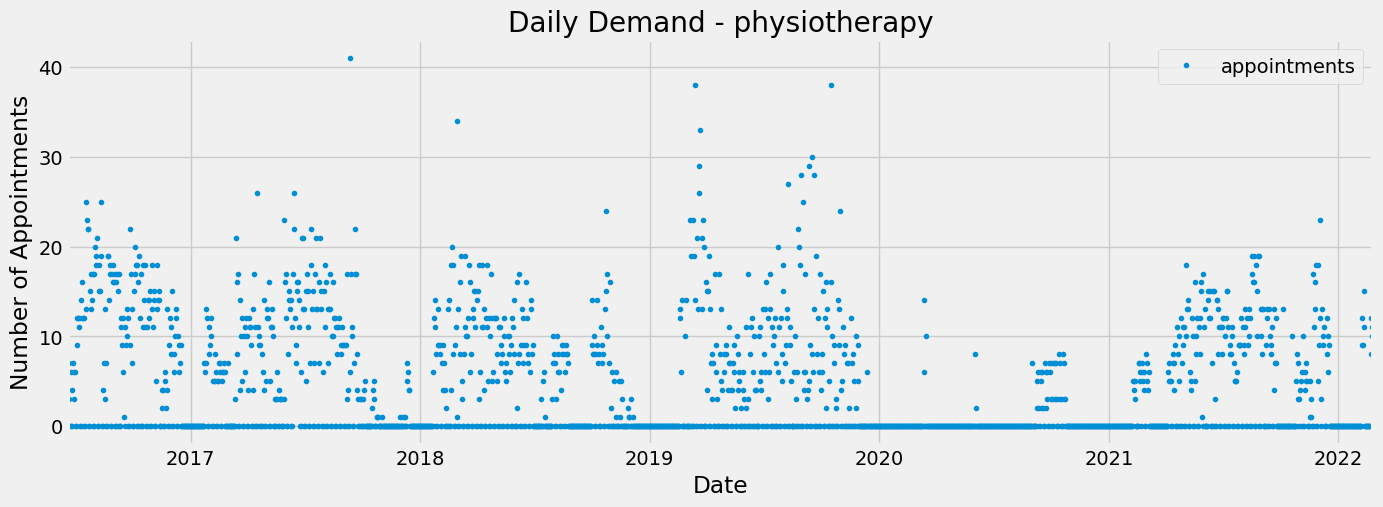

In [28]:
df_specialty.plot(
    style='.',
    figsize=(15, 5),
    color=color_pal[0],
    title=f'Daily Demand - {specialty}'
)

plt.ylabel('Number of Appointments')
plt.xlabel('Date')
plt.show()

Con esto ya deberíamos poder observar si la demanda tiene:

tendencia creciente/decreciente

estacionalidad semanal,

cambios por periodos,

valores atípicos,

periodos de baja demanda.

### Antes del Train/Test Split

In [29]:
print(df_specialty.index.min())
print(df_specialty.index.max())
print(len(df_specialty))

2016-06-20 00:00:00
2022-02-25 00:00:00
2077


### Train/Test Split

In [30]:
split_date = '2021-08-25'

train = df_specialty.loc[df_specialty.index < split_date].copy()
test = df_specialty.loc[df_specialty.index >= split_date].copy()

print('Training:', train.index.min(), '→', train.index.max())
print('Testing :', test.index.min(), '→', test.index.max())
print('Train shape:', train.shape)
print('Test shape:', test.shape)

Training: 2016-06-20 00:00:00 → 2021-08-24 00:00:00
Testing : 2021-08-25 00:00:00 → 2022-02-25 00:00:00
Train shape: (1892, 1)
Test shape: (185, 1)


## Grafico 

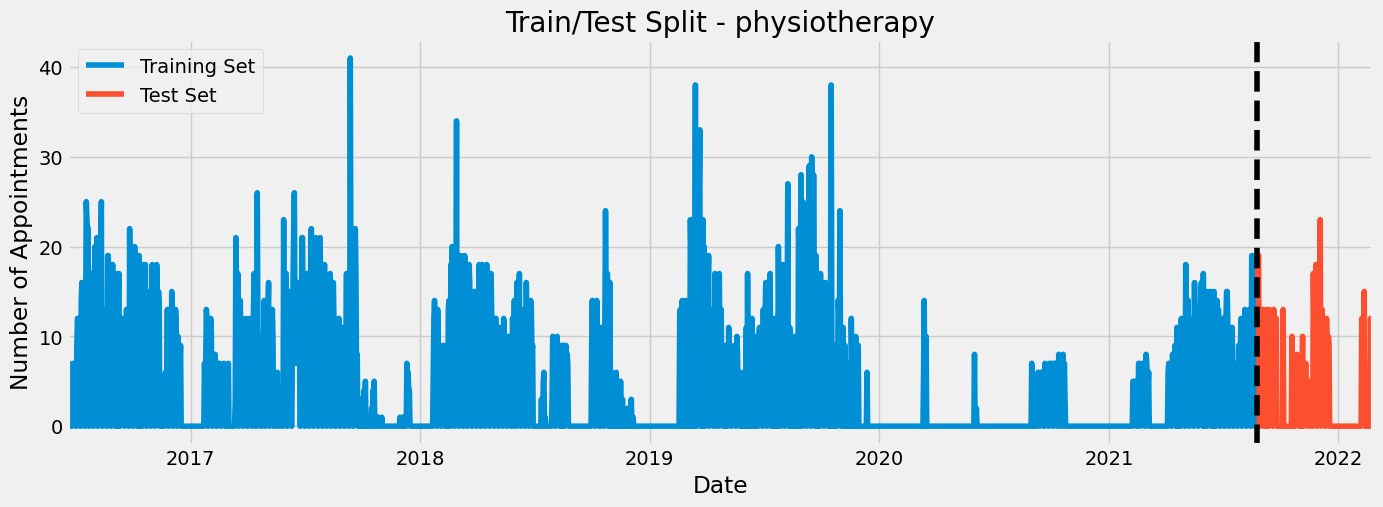

In [31]:
fig, ax = plt.subplots(figsize=(15, 5))

train['appointments'].plot(
    ax=ax,
    label='Training Set'
)

test['appointments'].plot(
    ax=ax,
    label='Test Set'
)

ax.axvline(
    pd.to_datetime(split_date),
    color='black',
    ls='--'
)

ax.set_title(
    f'Train/Test Split - {specialty}'
)

ax.set_ylabel('Number of Appointments')
ax.set_xlabel('Date')

ax.legend()

plt.show()

### Visualizar una semana de datos

In [32]:
week = df_specialty.loc[
    '2021-08-01':'2021-08-07'
]

week

,appointments
appointment_date,
2021-08-01,0.0
2021-08-02,11.0
2021-08-03,9.0
2021-08-04,8.0
2021-08-05,13.0
2021-08-06,11.0
2021-08-07,0.0


grafico

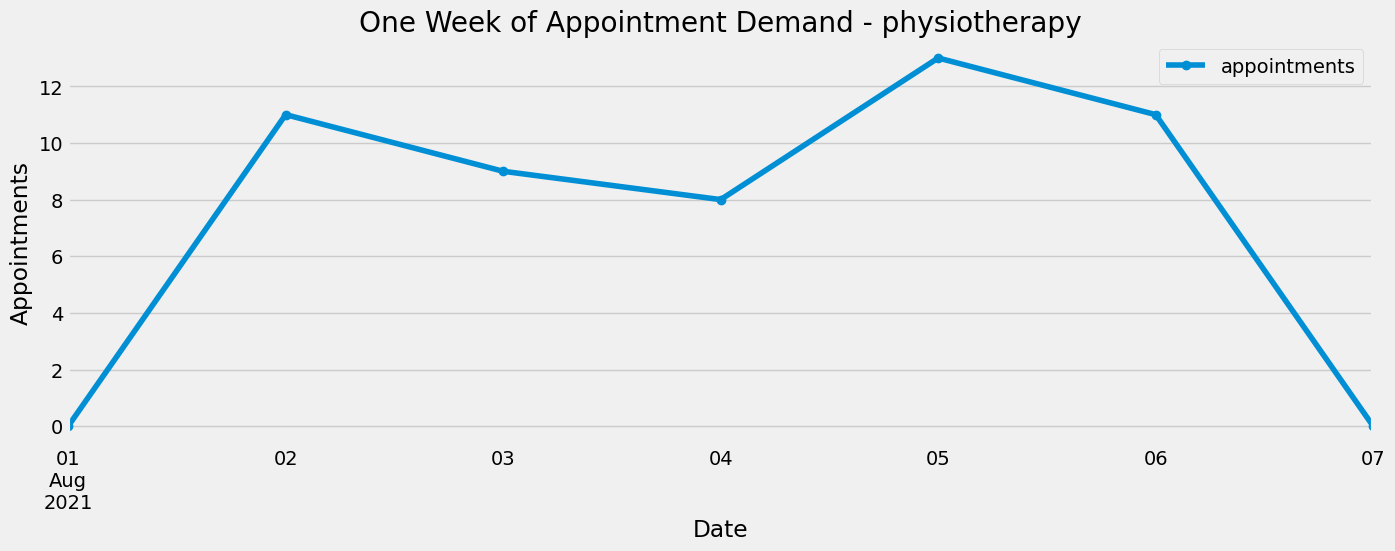

In [33]:
week.plot(
    figsize=(15, 5),
    marker='o',
    title=f'One Week of Appointment Demand - {specialty}'
)

plt.ylabel('Appointments')
plt.xlabel('Date')
plt.show()

### Cremos las variables temporales 

In [35]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    
    df = df.copy()

    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week.astype(int)

    return df

In [37]:
train = create_features(train)
test = create_features(test)

In [38]:
train.head()

,appointments,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
appointment_date,,,,,,,,
2016-06-20,7.0,0,2,6,2016,172,20,25
2016-06-21,7.0,1,2,6,2016,173,21,25
2016-06-22,3.0,2,2,6,2016,174,22,25
2016-06-23,0.0,3,2,6,2016,175,23,25
2016-06-24,6.0,4,2,6,2016,176,24,25


### Analizar demanda segun dia de la semana 

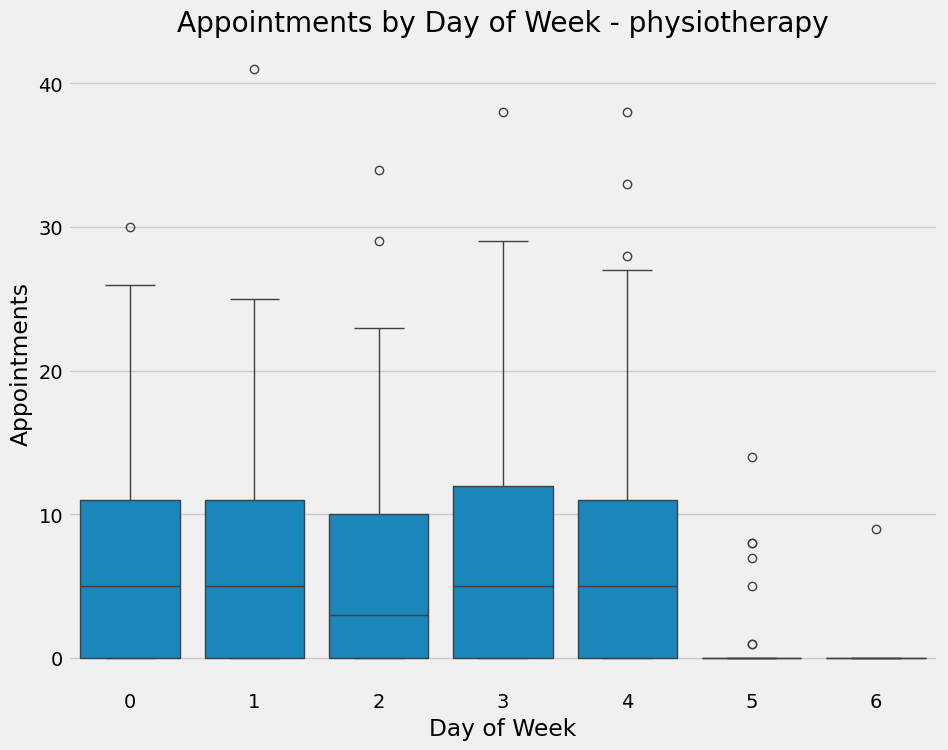

In [39]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.boxplot(
    data=train,
    x='dayofweek',
    y='appointments'
)

ax.set_title(
    f'Appointments by Day of Week - {specialty}'
)

ax.set_xlabel('Day of Week')
ax.set_ylabel('Appointments')

plt.show()

### Analizar demanda por mes

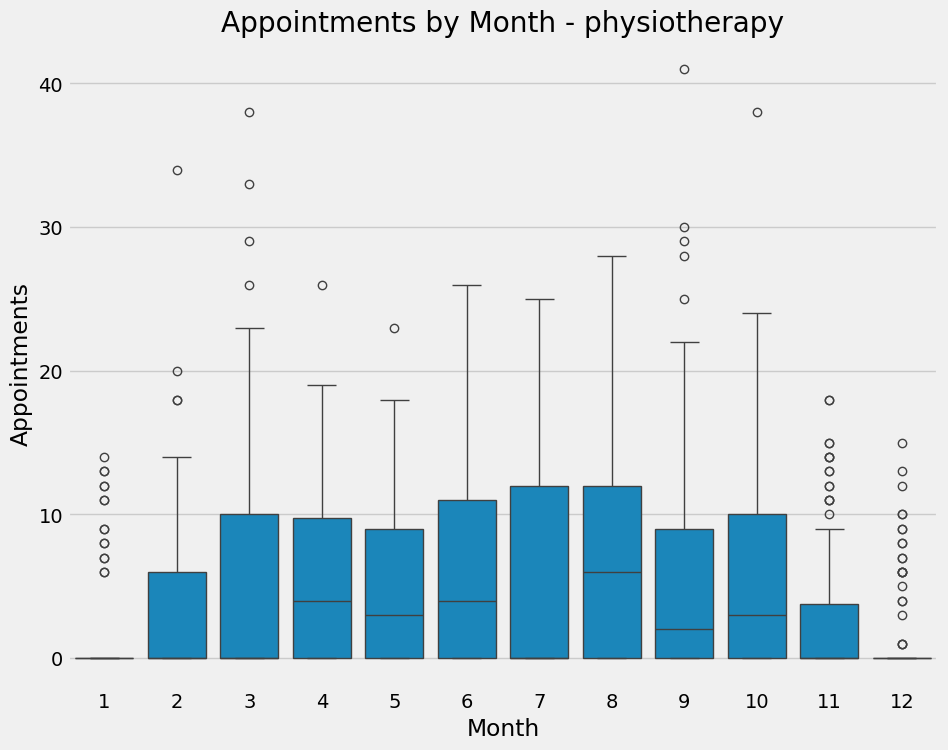

In [40]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.boxplot(
    data=train,
    x='month',
    y='appointments'
)

ax.set_title(
    f'Appointments by Month - {specialty}'
)

ax.set_xlabel('Month')
ax.set_ylabel('Appointments')

plt.show()

### Definir FEATURES y TARGET

In [41]:
FEATURES = [
    'dayofyear',
    'dayofweek',
    'quarter',
    'month',
    'year',
    'dayofmonth',
    'weekofyear'
]

TARGET = 'appointments'
X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [42]:
print('X_train:', X_train.shape)
print('y_train:', y_train.shape)

print('X_test:', X_test.shape)
print('y_test:', y_test.shape)

X_train: (1892, 7)
y_train: (1892,)
X_test: (185, 7)
y_test: (185,)


### Aplicamos : XGBoost

In [44]:
objective='reg:squarederror'

El modelo 

In [45]:
reg = xgb.XGBRegressor(
    base_score=0.5,
    booster='gbtree',
    n_estimators=1000,
    early_stopping_rounds=50,
    objective='reg:squarederror',
    max_depth=3,
    learning_rate=0.01
)

Realizamos el entranmiento:

In [46]:
reg.fit(
    X_train,
    y_train,
    eval_set=[
        (X_train, y_train),
        (X_test, y_test)
    ],
    verbose=100
)

[0]	validation_0-rmse:7.42005	validation_1-rmse:6.33889
[100]	validation_0-rmse:5.29149	validation_1-rmse:5.05123
[200]	validation_0-rmse:4.68957	validation_1-rmse:4.85363
[263]	validation_0-rmse:4.51824	validation_1-rmse:4.85939


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

## Empaquetamos el Modelo

In [77]:
import os

os.makedirs('/kaggle/working/model', exist_ok=True)

# Guardar modelo XGBoost
reg.save_model('/kaggle/working/model/medical_demand_xgb.json')

# Guardar las variables que utiliza el modelo
with open('/kaggle/working/model/features.txt', 'w') as f:
    for feature in FEATURES:
        f.write(feature + '\n')

print("Modelo guardado correctamente.")

Modelo guardado correctamente.


Comprobamos 


In [78]:
import os

for root, dirs, files in os.walk('/kaggle/working/model'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/working/model/features.txt
/kaggle/working/model/medical_demand_xgb.json


### Feature Importance 
Primero queremos saber qué variables temporales está utilizando más el modelo.

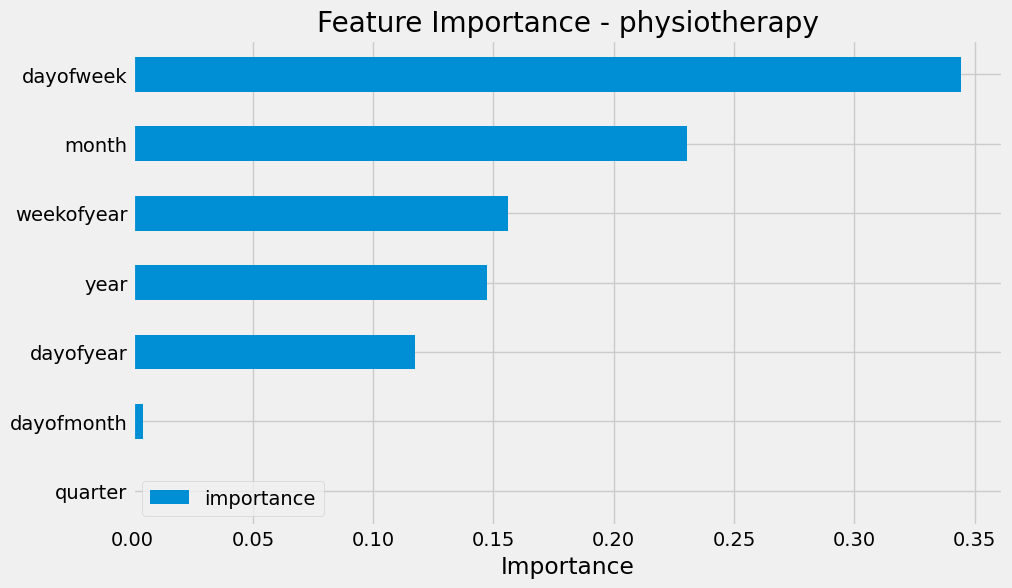

In [47]:
fi = pd.DataFrame(
    data=reg.feature_importances_,
    index=reg.feature_names_in_,
    columns=['importance']
)

fi.sort_values('importance').plot(
    kind='barh',
    figsize=(10, 6),
    title=f'Feature Importance - {specialty}'
)

plt.xlabel('Importance')
plt.show()

Ver los valores numericamente: 

In [48]:
fi.sort_values('importance', ascending=False)

,importance
dayofweek,0.344425
month,0.230361
weekofyear,0.156095
year,0.147513
dayofyear,0.117379
dayofmonth,0.004226
quarter,0.000000


### Generar las predicciones 

In [50]:
test['prediction'] = reg.predict(X_test)

Ignoramos el lado negativo ya que las citas no pueden ser menores a 0 

In [52]:
test['prediction'] = test['prediction'].clip(lower=0)

Revisamos algunas predicciones

In [53]:
test[['appointments', 'prediction']].head(15)

,appointments,prediction
appointment_date,,
2021-08-25,15.0,6.748520
2021-08-26,19.0,6.748520
2021-08-27,19.0,6.748520
2021-08-28,0.0,1.465170
2021-08-29,0.0,1.399411
2021-08-30,13.0,6.748520
2021-08-31,10.0,6.748520
2021-09-01,8.0,6.748520
2021-09-02,13.0,6.748520


### Visualizar Truth vs Predictions

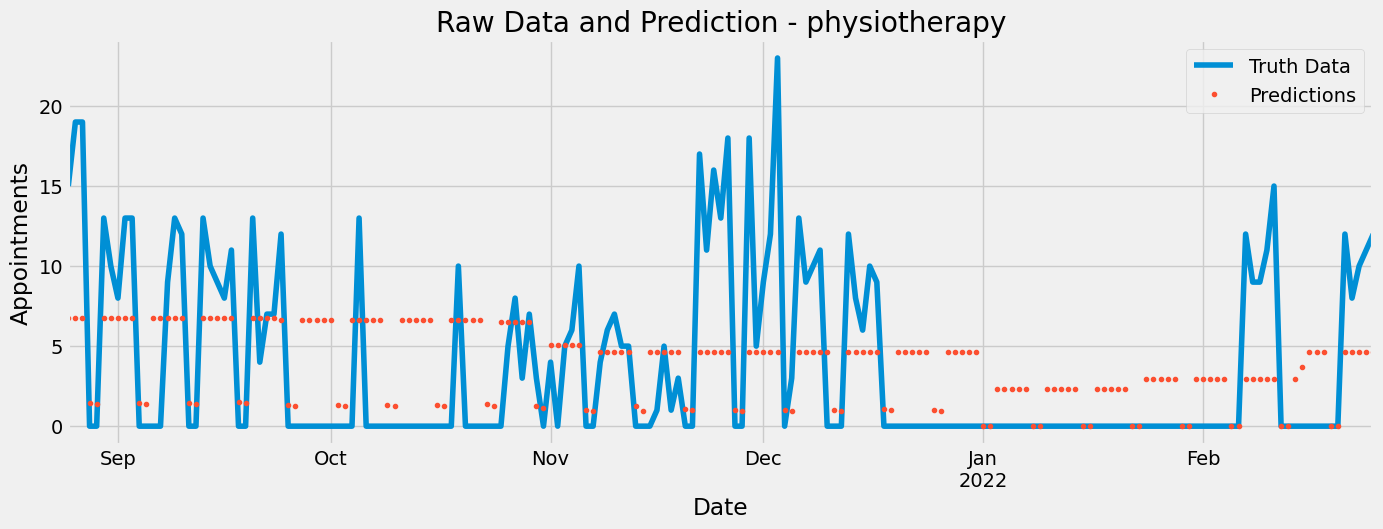

In [54]:
ax = test[['appointments']].plot(
    figsize=(15, 5),
    title=f'Raw Data and Prediction - {specialty}'
)

test['prediction'].plot(
    ax=ax,
    style='.'
)

plt.legend([
    'Truth Data',
    'Predictions'
])

plt.ylabel('Appointments')
plt.xlabel('Date')

plt.show()

### Calcular RMSE

In [55]:
score = np.sqrt(
    mean_squared_error(
        test['appointments'],
        test['prediction']
    )
)

print(f'RMSE Score on Test set: {score:0.2f}')

RMSE Score on Test set: 4.85


### Analizar los Errores

In [70]:
test['error'] = np.abs(
    test[TARGET] - test['prediction']
)

In [72]:
test['date'] = test.index.date

In [73]:
test.groupby('date')['error'] \
    .mean() \
    .sort_values(ascending=False) \
    .head(10)

date
2021-12-03    18.358359
2021-11-29    13.358359
2021-11-26    13.358359
2021-11-22    12.358359
2021-08-26    12.251480
2021-08-27    12.251480
2022-02-11    12.071293
2021-11-24    11.358359
2022-02-07     9.071293
2021-11-25     8.358359
Name: error, dtype: float64

### Ver los días problemáticos con más detalle

In [74]:
worst_days = (
    test.groupby('date')['error']
        .mean()
        .sort_values(ascending=False)
        .head(10)
)

worst_days

date
2021-12-03    18.358359
2021-11-29    13.358359
2021-11-26    13.358359
2021-11-22    12.358359
2021-08-26    12.251480
2021-08-27    12.251480
2022-02-11    12.071293
2021-11-24    11.358359
2022-02-07     9.071293
2021-11-25     8.358359
Name: error, dtype: float64

In [75]:
test.loc[
    test['date'].isin(worst_days.index),
    ['appointments', 'prediction', 'error']
].sort_values(
    'error',
    ascending=False
).head(20)

,appointments,prediction,error
appointment_date,,,
2021-12-03,23.0,4.641641,18.358359
2021-11-26,18.0,4.641641,13.358359
2021-11-29,18.0,4.641641,13.358359
2021-11-22,17.0,4.641641,12.358359
2021-08-27,19.0,6.748520,12.251480
2021-08-26,19.0,6.748520,12.251480
2022-02-11,15.0,2.928707,12.071293
2021-11-24,16.0,4.641641,11.358359
2022-02-07,12.0,2.928707,9.071293


### Guardar los resultados del Baseline

In [76]:
baseline_rmse = score

print(f'Baseline RMSE ({specialty}): {baseline_rmse:.2f}')

Baseline RMSE (physiotherapy): 4.85


## Para todas las especialidades
Primero reinicia la sesion y ejecuta solo el sig conmando 

MEDICITAS - FORECASTING DE DEMANDA
Ruta de datos: /kaggle/input/datasets/joker1223335f/medical-appointments-no-show/Medical Appointments No-Show/medical-appointments-no-show-en.csv
Ruta de salida: /kaggle/working/models
Fecha de separación: 2021-08-25


CARGANDO DATASET
Shape: (49593, 26)


,specialty,appointment_time,gender,appointment_date,no_show,no_show_reason,disability,date_of_birth,entry_service_date,city,...,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,rainy_day_before,storm_day_before,rain_intensity,heat_intensity
0,physiotherapy,13:20,M,09/09/2021,yes,surto,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
1,psychotherapy,13:20,M,09/09/2021,no,NaN,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
2,speech therapy,13:20,F,09/09/2021,no,NaN,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
3,physiotherapy,13:20,F,09/09/2021,no,NaN,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
4,physiotherapy,14:00,M,09/09/2021,no,NaN,motor,10/10/1954,5/2/2020,B. CAMBORIU,...,1,1,20.75,0.01,23.7,0.2,1,1,no_rain,mild




INFORMACIÓN DEL DATASET

Columnas:
['specialty', 'appointment_time', 'gender', 'appointment_date', 'no_show', 'no_show_reason', 'disability', 'date_of_birth', 'entry_service_date', 'city', 'icd', 'appointment_month', 'appointment_year', 'appointment_shift', 'age', 'under_12_years_old', 'over_60_years_old', 'patient_needs_companion', 'average_temp_day', 'average_rain_day', 'max_temp_day', 'max_rain_day', 'rainy_day_before', 'storm_day_before', 'rain_intensity', 'heat_intensity']

Información:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49593 entries, 0 to 49592
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   specialty                42139 non-null  object 
 1   appointment_time         49593 non-null  object 
 2   gender                   49593 non-null  object 
 3   appointment_date         49593 non-null  object 
 4   no_show                  49593 non-null  object 
 5   no_show_r

specialty                   7454
appointment_time               0
gender                         0
appointment_date               0
no_show                        0
no_show_reason             47856
disability                  5137
date_of_birth              10321
entry_service_date          5155
city                        5181
icd                        38876
appointment_month              0
appointment_year               0
appointment_shift              0
age                        10350
under_12_years_old             0
over_60_years_old              0
patient_needs_companion        0
average_temp_day            1016
average_rain_day            1016
max_temp_day                1016
max_rain_day                1016
rainy_day_before               0
storm_day_before               0
rain_intensity                 0
heat_intensity                 0
dtype: int64


Duplicados: 2921


CONVERSIÓN DE FECHAS
Fecha mínima: 2016-06-20 00:00:00
Fecha máxima: 2022-02-25 00:00:00
Fechas inválidas: 0
Shape después de limpieza: (42139, 26)


CONSTRUYENDO DEMANDA DIARIA POR ESPECIALIDAD
Shape: (4210, 3)


,appointment_date,specialty,appointments
0,2016-06-20,occupational therapy,4
1,2016-06-20,pedagogo,4
2,2016-06-20,physiotherapy,7
3,2016-06-20,psychotherapy,5
4,2016-06-20,speech therapy,10
5,2016-06-21,occupational therapy,3
6,2016-06-21,pedagogo,7
7,2016-06-21,physiotherapy,7
8,2016-06-21,psychotherapy,14
9,2016-06-21,speech therapy,9



Número de especialidades: 8

Especialidades encontradas:
01. assist
02. enf
03. occupational therapy
04. pedagogo
05. physiotherapy
06. psychotherapy
07. sem especialidade
08. speech therapy


Features:
['dayofyear', 'dayofweek', 'quarter', 'month', 'year', 'dayofmonth', 'weekofyear']
Target: appointments


INICIANDO ENTRENAMIENTO


######################################################################
ESPECIALIDAD: assist
######################################################################
⚠️ ESPECIALIDAD OMITIDA
No hay suficientes datos para Train / Validation / Test.


######################################################################
ESPECIALIDAD: enf
######################################################################
Entrenando XGBoost...
✓ Modelo guardado: enf.json
✓ RMSE: 0.84
✓ MAE: 0.25
✓ Train: 1768
✓ Validation: 60
✓ Test: 63


######################################################################
ESPECIALIDAD: occupational therapy
#################################

,specialty,rmse,mae,train_rows,validation_rows,test_rows,model_file
0,enf,0.835363,0.249305,1768,60,63,enf.json
1,occupational therapy,3.460902,2.669376,1832,60,185,occupational_therapy.json
2,physiotherapy,5.129288,3.820981,1832,60,185,physiotherapy.json
3,psychotherapy,5.337283,3.869716,1832,60,185,psychotherapy.json
4,speech therapy,4.983224,3.933067,1832,60,185,speech_therapy.json


✓ Métricas guardadas: /kaggle/working/models/model_metrics.csv
✓ Información guardada: /kaggle/working/models/models_info.json
✓ Features guardadas: /kaggle/working/models/features.json


FEATURE IMPORTANCE - physiotherapy


,importance
month,0.333989
dayofweek,0.271630
year,0.151615
dayofyear,0.108510
weekofyear,0.072156
quarter,0.048792
dayofmonth,0.013309


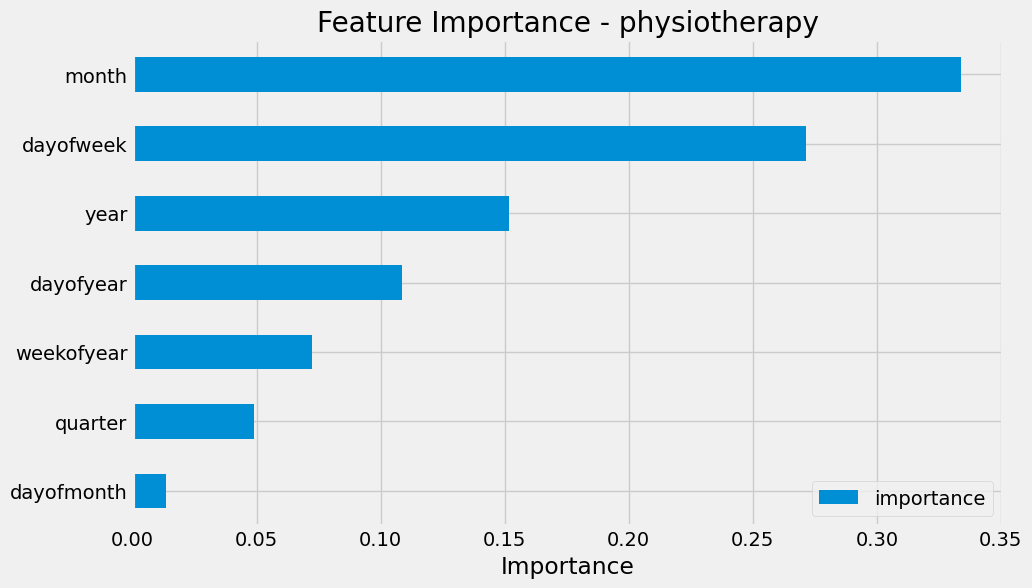



VERIFICANDO MODELOS
✓ enf → enf.json
✓ occupational therapy → occupational_therapy.json
✓ physiotherapy → physiotherapy.json
✓ psychotherapy → psychotherapy.json
✓ speech therapy → speech_therapy.json

Modelos cargados correctamente: 5


PREDICCIONES PARA LOS PRÓXIMOS 14 DÍAS


,appointment_date,specialty,predicted_appointments
0,2022-02-26,enf,0.000000
1,2022-02-27,enf,0.089959
2,2022-02-28,enf,0.344307
3,2022-03-01,enf,0.068610
4,2022-03-02,enf,0.080649
5,2022-03-03,enf,0.080649
6,2022-03-04,enf,0.196129
7,2022-03-05,enf,0.028438
8,2022-03-06,enf,0.028438
9,2022-03-07,enf,0.128467


✓ Predicciones guardadas: /kaggle/working/models/future_predictions.csv


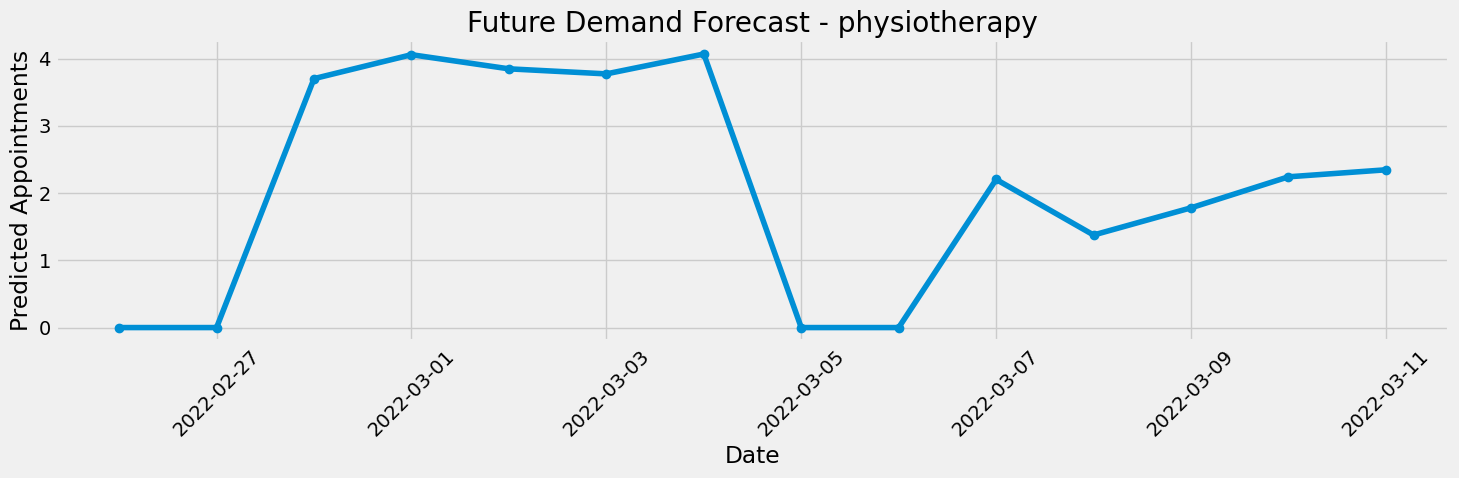

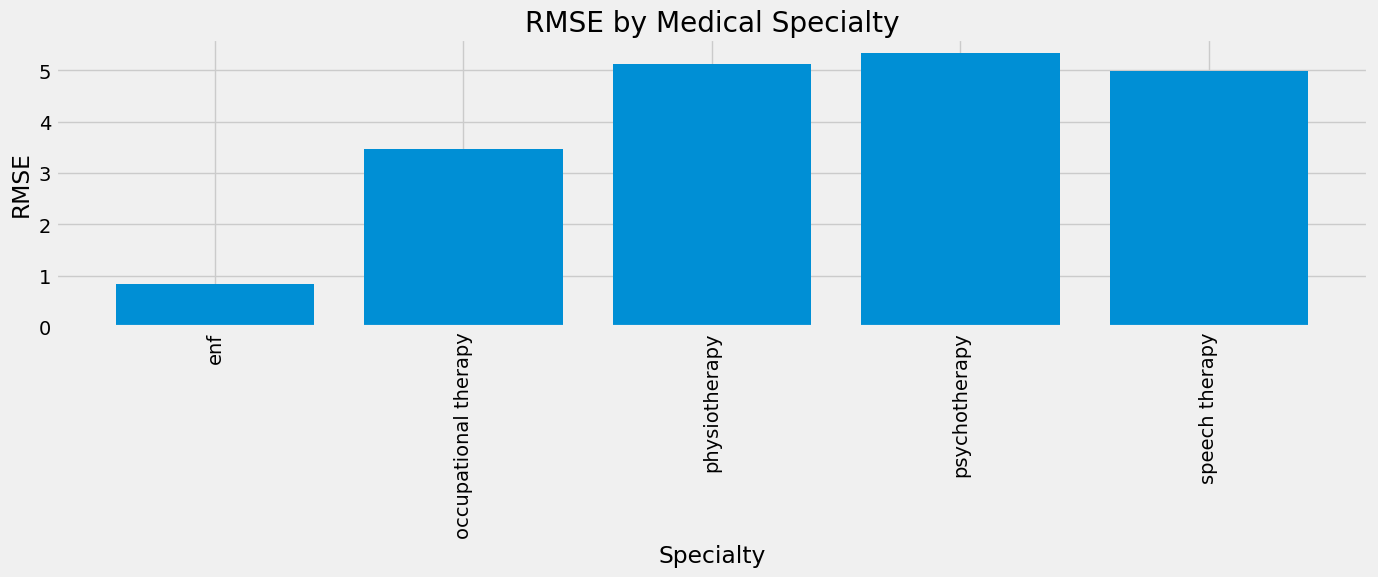



ARCHIVOS GENERADOS
enf.json                                    442.28 KB
features.json                                 0.11 KB
future_predictions.csv                        2.37 KB
model_metrics.csv                             0.46 KB
models_info.json                              2.92 KB
occupational_therapy.json                  1100.57 KB
physiotherapy.json                         1104.97 KB
psychotherapy.json                         1100.02 KB
speech_therapy.json                         964.72 KB


PROCESO FINALIZADO
Especialidades encontradas: 8
Modelos entrenados: 5
Carpeta de modelos: /kaggle/working/models

Archivos principales:
✓ [especialidad].json
✓ features.json
✓ models_info.json
✓ model_metrics.csv
✓ future_predictions.csv

¡Proceso completado!


In [1]:
# ============================================================
# MEDICITAS
# PRONÓSTICO DE DEMANDA DE CITAS POR ESPECIALIDAD
# XGBOOST - UN MODELO POR ESPECIALIDAD
# ============================================================


# ============================================================
# 1. IMPORTAR LIBRERÍAS
# ============================================================

import os
import re
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

SEED = 42
np.random.seed(SEED)


# ============================================================
# 2. CONFIGURACIÓN
# ============================================================

RUTA_DATOS = (
    '/kaggle/input/datasets/joker1223335f/'
    'medical-appointments-no-show/'
    'Medical Appointments No-Show/'
    'medical-appointments-no-show-en.csv'
)

RUTA_SALIDA = Path(
    '/kaggle/working/models'
)

RUTA_SALIDA.mkdir(
    parents=True,
    exist_ok=True
)

SPLIT_DATE = pd.Timestamp(
    '2021-08-25'
)

VALIDATION_DAYS = 60

HORIZONTE_DIAS = 14


print('=' * 70)
print('MEDICITAS - FORECASTING DE DEMANDA')
print('=' * 70)

print(
    'Ruta de datos:',
    RUTA_DATOS
)

print(
    'Ruta de salida:',
    RUTA_SALIDA
)

print(
    'Fecha de separación:',
    SPLIT_DATE.date()
)


# ============================================================
# 3. CARGAR DATASET
# ============================================================

print('\n')
print('=' * 70)
print('CARGANDO DATASET')
print('=' * 70)

df = pd.read_csv(
    RUTA_DATOS
)

print(
    'Shape:',
    df.shape
)

display(
    df.head()
)


# ============================================================
# 4. INFORMACIÓN DEL DATASET
# ============================================================

print('\n')
print('=' * 70)
print('INFORMACIÓN DEL DATASET')
print('=' * 70)

print('\nColumnas:')
print(
    df.columns.tolist()
)

print('\nInformación:')
df.info()

print('\nValores nulos:')
display(
    df.isna().sum()
)

print(
    '\nDuplicados:',
    df.duplicated().sum()
)


# ============================================================
# 5. CONVERTIR APPOINTMENT_DATE
# ============================================================

print('\n')
print('=' * 70)
print('CONVERSIÓN DE FECHAS')
print('=' * 70)

df['appointment_date'] = pd.to_datetime(
    df['appointment_date'],
    format='%d/%m/%Y',
    errors='coerce'
)

print(
    'Fecha mínima:',
    df['appointment_date'].min()
)

print(
    'Fecha máxima:',
    df['appointment_date'].max()
)

print(
    'Fechas inválidas:',
    df['appointment_date'].isna().sum()
)


# Eliminar registros sin fecha o especialidad
df = df.dropna(
    subset=[
        'appointment_date',
        'specialty'
    ]
).copy()

print(
    'Shape después de limpieza:',
    df.shape
)


# ============================================================
# 6. CREAR DEMANDA DIARIA POR ESPECIALIDAD
# ============================================================

print('\n')
print('=' * 70)
print('CONSTRUYENDO DEMANDA DIARIA POR ESPECIALIDAD')
print('=' * 70)

daily_specialty = (
    df.groupby(
        [
            'appointment_date',
            'specialty'
        ]
    )
    .size()
    .reset_index(
        name='appointments'
    )
)

print(
    'Shape:',
    daily_specialty.shape
)

display(
    daily_specialty.head(20)
)


# ============================================================
# 7. OBTENER TODAS LAS ESPECIALIDADES
# ============================================================

specialties = sorted(
    daily_specialty[
        'specialty'
    ].unique()
)

print(
    '\nNúmero de especialidades:',
    len(specialties)
)

print('\nEspecialidades encontradas:')

for i, specialty in enumerate(
    specialties,
    start=1
):
    print(
        f'{i:02d}. {specialty}'
    )


# ============================================================
# 8. DEFINIR FEATURES Y TARGET
# ============================================================

FEATURES = [
    'dayofyear',
    'dayofweek',
    'quarter',
    'month',
    'year',
    'dayofmonth',
    'weekofyear'
]

TARGET = 'appointments'


print('\n')
print('Features:')
print(FEATURES)

print(
    'Target:',
    TARGET
)


# ============================================================
# 9. FUNCIÓN PARA CREAR FEATURES
# ============================================================

def create_features(data):

    data = data.copy()

    data['dayofweek'] = (
        data.index.dayofweek
    )

    data['quarter'] = (
        data.index.quarter
    )

    data['month'] = (
        data.index.month
    )

    data['year'] = (
        data.index.year
    )

    data['dayofyear'] = (
        data.index.dayofyear
    )

    data['dayofmonth'] = (
        data.index.day
    )

    data['weekofyear'] = (
        data.index
        .isocalendar()
        .week
        .astype(int)
    )

    return data


# ============================================================
# 10. FUNCIÓN PARA CREAR NOMBRES DE ARCHIVO
# ============================================================

def safe_filename(text):

    text = str(
        text
    ).strip().lower()

    text = (
        text
        .replace('á', 'a')
        .replace('é', 'e')
        .replace('í', 'i')
        .replace('ó', 'o')
        .replace('ú', 'u')
        .replace('ñ', 'n')
    )

    text = re.sub(
        r'[^a-z0-9]+',
        '_',
        text
    )

    return text.strip('_')


# ============================================================
# 11. ENTRENAMIENTO AUTOMÁTICO
#     UN XGBOOST POR CADA ESPECIALIDAD
# ============================================================

print('\n')
print('=' * 70)
print('INICIANDO ENTRENAMIENTO')
print('=' * 70)


results = []

models_info = {}

trained_models = {}


for specialty in specialties:

    print('\n')
    print('#' * 70)
    print(
        f'ESPECIALIDAD: {specialty}'
    )
    print('#' * 70)


    # --------------------------------------------------------
    # FILTRAR ESPECIALIDAD
    # --------------------------------------------------------

    df_specialty = daily_specialty[
        daily_specialty['specialty']
        == specialty
    ].copy()


    # --------------------------------------------------------
    # SELECCIONAR COLUMNAS
    # --------------------------------------------------------

    df_specialty = df_specialty[
        [
            'appointment_date',
            'appointments'
        ]
    ].copy()


    # --------------------------------------------------------
    # CONVERTIR FECHA EN ÍNDICE
    # --------------------------------------------------------

    df_specialty = (
        df_specialty
        .set_index(
            'appointment_date'
        )
        .sort_index()
    )


    # --------------------------------------------------------
    # FRECUENCIA DIARIA
    # --------------------------------------------------------

    df_specialty = (
        df_specialty
        .asfreq('D')
    )


    # Días sin citas = 0
    df_specialty[
        'appointments'
    ] = (
        df_specialty[
            'appointments'
        ]
        .fillna(0)
    )


    # --------------------------------------------------------
    # COMPROBAR DATOS SUFICIENTES
    # --------------------------------------------------------

    if len(df_specialty) < 180:

        print(
            '⚠️ ESPECIALIDAD OMITIDA'
        )

        print(
            'Días disponibles:',
            len(df_specialty)
        )

        continue


    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    train_full = (
        df_specialty.loc[
            df_specialty.index
            < SPLIT_DATE
        ]
        .copy()
    )


    # --------------------------------------------------------
    # TEST
    # --------------------------------------------------------

    test = (
        df_specialty.loc[
            df_specialty.index
            >= SPLIT_DATE
        ]
        .copy()
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    validation_start = (
        train_full.index.max()
        -
        pd.Timedelta(
            days=VALIDATION_DAYS - 1
        )
    )


    train = (
        train_full.loc[
            train_full.index
            < validation_start
        ]
        .copy()
    )


    validation = (
        train_full.loc[
            train_full.index
            >= validation_start
        ]
        .copy()
    )


    # --------------------------------------------------------
    # COMPROBAR TRAIN / VALIDATION / TEST
    # --------------------------------------------------------

    if (
        len(train) == 0
        or len(validation) == 0
        or len(test) == 0
    ):

        print(
            '⚠️ ESPECIALIDAD OMITIDA'
        )

        print(
            'No hay suficientes datos '
            'para Train / Validation / Test.'
        )

        continue


    # --------------------------------------------------------
    # CREAR FEATURES
    # --------------------------------------------------------

    train = create_features(
        train
    )

    validation = create_features(
        validation
    )

    test = create_features(
        test
    )


    # --------------------------------------------------------
    # X TRAIN / Y TRAIN
    # --------------------------------------------------------

    X_train = train[
        FEATURES
    ]

    y_train = train[
        TARGET
    ]


    # --------------------------------------------------------
    # X VALIDATION / Y VALIDATION
    # --------------------------------------------------------

    X_validation = validation[
        FEATURES
    ]

    y_validation = validation[
        TARGET
    ]


    # --------------------------------------------------------
    # X TEST / Y TEST
    # --------------------------------------------------------

    X_test = test[
        FEATURES
    ]

    y_test = test[
        TARGET
    ]


    # --------------------------------------------------------
    # CREAR MODELO
    # --------------------------------------------------------

    reg = xgb.XGBRegressor(

        base_score=0.5,

        booster='gbtree',

        n_estimators=1000,

        early_stopping_rounds=50,

        objective='reg:squarederror',

        max_depth=3,

        learning_rate=0.01,

        random_state=SEED
    )


    # --------------------------------------------------------
    # ENTRENAR
    # --------------------------------------------------------

    print(
        'Entrenando XGBoost...'
    )


    reg.fit(

        X_train,

        y_train,

        eval_set=[
            (
                X_validation,
                y_validation
            )
        ],

        verbose=False
    )


    # --------------------------------------------------------
    # PREDICCIONES TEST
    # --------------------------------------------------------

    predictions = (
        reg.predict(
            X_test
        )
    )


    # Evitar predicciones negativas
    predictions = np.clip(
        predictions,
        a_min=0,
        a_max=None
    )


    # --------------------------------------------------------
    # RMSE
    # --------------------------------------------------------

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )


    # --------------------------------------------------------
    # MAE
    # --------------------------------------------------------

    mae = mean_absolute_error(
        y_test,
        predictions
    )


    # --------------------------------------------------------
    # NOMBRE DEL ARCHIVO
    # --------------------------------------------------------

    specialty_file = (
        safe_filename(
            specialty
        )
    )


    model_path = (
        RUTA_SALIDA
        /
        f'{specialty_file}.json'
    )


    # --------------------------------------------------------
    # GUARDAR MODELO
    # --------------------------------------------------------

    reg.save_model(
        str(model_path)
    )


    # --------------------------------------------------------
    # GUARDAR MODELO EN MEMORIA
    # --------------------------------------------------------

    trained_models[
        specialty
    ] = reg


    # --------------------------------------------------------
    # INFORMACIÓN DEL MODELO
    # --------------------------------------------------------

    models_info[
        specialty
    ] = {

        'specialty':
            specialty,

        'model_file':
            model_path.name,

        'rmse':
            float(rmse),

        'mae':
            float(mae),

        'train_rows':
            int(len(train)),

        'validation_rows':
            int(len(validation)),

        'test_rows':
            int(len(test)),

        'date_min':
            str(
                df_specialty
                .index
                .min()
                .date()
            ),

        'date_max':
            str(
                df_specialty
                .index
                .max()
                .date()
            ),

        'split_date':
            str(
                SPLIT_DATE.date()
            ),

        'features':
            FEATURES,

        'best_iteration':
            (
                int(
                    reg.best_iteration
                )
                if reg.best_iteration
                is not None
                else None
            )
    }


    # --------------------------------------------------------
    # GUARDAR RESULTADOS
    # --------------------------------------------------------

    results.append({

        'specialty':
            specialty,

        'rmse':
            rmse,

        'mae':
            mae,

        'train_rows':
            len(train),

        'validation_rows':
            len(validation),

        'test_rows':
            len(test),

        'model_file':
            model_path.name
    })


    # --------------------------------------------------------
    # MOSTRAR RESULTADOS
    # --------------------------------------------------------

    print(
        '✓ Modelo guardado:',
        model_path.name
    )

    print(
        f'✓ RMSE: {rmse:.2f}'
    )

    print(
        f'✓ MAE: {mae:.2f}'
    )

    print(
        f'✓ Train: {len(train)}'
    )

    print(
        f'✓ Validation: {len(validation)}'
    )

    print(
        f'✓ Test: {len(test)}'
    )


# ============================================================
# 12. FIN DEL ENTRENAMIENTO
# ============================================================

print('\n')
print('=' * 70)
print('ENTRENAMIENTO TERMINADO')
print('=' * 70)

print(
    'Modelos entrenados:',
    len(trained_models)
)

print(
    'Especialidades detectadas:',
    len(specialties)
)


# ============================================================
# 13. TABLA DE RESULTADOS
# ============================================================

results_df = pd.DataFrame(
    results
)


if len(results_df) > 0:

    results_df = (
        results_df
        .sort_values(
            'specialty'
        )
        .reset_index(
            drop=True
        )
    )


    print('\n')
    print('=' * 70)
    print('RESULTADOS DE LOS MODELOS')
    print('=' * 70)


    display(
        results_df
    )


# ============================================================
# 14. GUARDAR MÉTRICAS
# ============================================================

metrics_path = (
    RUTA_SALIDA
    /
    'model_metrics.csv'
)


results_df.to_csv(
    metrics_path,
    index=False
)


print(
    '✓ Métricas guardadas:',
    metrics_path
)


# ============================================================
# 15. GUARDAR INFORMACIÓN DE LOS MODELOS
# ============================================================

models_info_path = (
    RUTA_SALIDA
    /
    'models_info.json'
)


with open(
    models_info_path,
    'w',
    encoding='utf-8'
) as f:

    json.dump(
        models_info,
        f,
        indent=4,
        ensure_ascii=False
    )


print(
    '✓ Información guardada:',
    models_info_path
)


# ============================================================
# 16. GUARDAR FEATURES
# ============================================================

features_path = (
    RUTA_SALIDA
    /
    'features.json'
)


with open(
    features_path,
    'w',
    encoding='utf-8'
) as f:

    json.dump(
        FEATURES,
        f,
        indent=4
    )


print(
    '✓ Features guardadas:',
    features_path
)


# ============================================================
# 17. FEATURE IMPORTANCE
# ============================================================

if len(trained_models) > 0:

    if (
        'physiotherapy'
        in trained_models
    ):

        example_specialty = (
            'physiotherapy'
        )

    else:

        example_specialty = (
            list(
                trained_models.keys()
            )[0]
        )


    example_model = (
        trained_models[
            example_specialty
        ]
    )


    fi = pd.DataFrame(

        data=
            example_model.feature_importances_,

        index=FEATURES,

        columns=[
            'importance'
        ]
    )


    print('\n')
    print('=' * 70)
    print(
        f'FEATURE IMPORTANCE - '
        f'{example_specialty}'
    )
    print('=' * 70)


    display(
        fi.sort_values(
            'importance',
            ascending=False
        )
    )


    fi.sort_values(
        'importance'
    ).plot(

        kind='barh',

        figsize=(10, 6),

        title=(
            f'Feature Importance - '
            f'{example_specialty}'
        )
    )


    plt.xlabel(
        'Importance'
    )

    plt.show()


# ============================================================
# 18. COMPROBAR QUE TODOS LOS MODELOS SE PUEDAN CARGAR
# ============================================================

print('\n')
print('=' * 70)
print('VERIFICANDO MODELOS')
print('=' * 70)


loaded_models = {}


for specialty in specialties:

    model_path = (
        RUTA_SALIDA
        /
        f'{safe_filename(specialty)}.json'
    )


    if not model_path.exists():

        continue


    model = (
        xgb.XGBRegressor()
    )


    model.load_model(
        str(model_path)
    )


    loaded_models[
        specialty
    ] = model


    print(
        '✓',
        specialty,
        '→',
        model_path.name
    )


print(
    '\nModelos cargados correctamente:',
    len(loaded_models)
)


# ============================================================
# 19. PREDICCIONES FUTURAS
# ============================================================

print('\n')
print('=' * 70)
print(
    f'PREDICCIONES PARA LOS '
    f'PRÓXIMOS {HORIZONTE_DIAS} DÍAS'
)
print('=' * 70)


future_results = []


ultima_fecha = (
    df[
        'appointment_date'
    ]
    .max()
)


fechas_futuras = pd.date_range(

    start=(
        ultima_fecha
        +
        pd.Timedelta(
            days=1
        )
    ),

    periods=HORIZONTE_DIAS,

    freq='D'
)


for specialty, model in (
    loaded_models.items()
):


    future = pd.DataFrame(
        index=fechas_futuras
    )


    future.index.name = (
        'appointment_date'
    )


    future = create_features(
        future
    )


    predictions = (
        model.predict(
            future[FEATURES]
        )
    )


    predictions = np.clip(
        predictions,
        a_min=0,
        a_max=None
    )


    temp = pd.DataFrame({

        'appointment_date':
            fechas_futuras,

        'specialty':
            specialty,

        'predicted_appointments':
            predictions
    })


    future_results.append(
        temp
    )


if len(future_results) > 0:

    future_predictions = pd.concat(
        future_results,
        ignore_index=True
    )


    display(
        future_predictions.head(30)
    )


    # --------------------------------------------------------
    # GUARDAR PREDICCIONES
    # --------------------------------------------------------

    future_path = (
        RUTA_SALIDA
        /
        'future_predictions.csv'
    )


    future_predictions.to_csv(
        future_path,
        index=False
    )


    print(
        '✓ Predicciones guardadas:',
        future_path
    )


# ============================================================
# 20. GRÁFICO DE PREDICCIÓN FUTURA
# ============================================================

if len(trained_models) > 0:

    if (
        'physiotherapy'
        in trained_models
    ):

        plot_specialty = (
            'physiotherapy'
        )

    else:

        plot_specialty = (
            list(
                trained_models.keys()
            )[0]
        )


    plot_data = (
        future_predictions[
            future_predictions[
                'specialty'
            ]
            == plot_specialty
        ]
        .copy()
    )


    plt.figure(
        figsize=(15, 5)
    )


    plt.plot(

        plot_data[
            'appointment_date'
        ],

        plot_data[
            'predicted_appointments'
        ],

        marker='o'
    )


    plt.title(
        f'Future Demand Forecast - '
        f'{plot_specialty}'
    )


    plt.xlabel(
        'Date'
    )


    plt.ylabel(
        'Predicted Appointments'
    )


    plt.xticks(
        rotation=45
    )


    plt.tight_layout()

    plt.show()


# ============================================================
# 21. GRÁFICO DE RMSE POR ESPECIALIDAD
# ============================================================

if len(results_df) > 0:

    plt.figure(
        figsize=(14, 6)
    )


    plt.bar(

        results_df[
            'specialty'
        ],

        results_df[
            'rmse'
        ]
    )


    plt.title(
        'RMSE by Medical Specialty'
    )


    plt.xlabel(
        'Specialty'
    )


    plt.ylabel(
        'RMSE'
    )


    plt.xticks(
        rotation=90
    )


    plt.tight_layout()

    plt.show()


# ============================================================
# 22. LISTAR ARCHIVOS FINALES
# ============================================================

print('\n')
print('=' * 70)
print('ARCHIVOS GENERADOS')
print('=' * 70)


for file in sorted(
    RUTA_SALIDA.iterdir()
):

    size_kb = (
        file.stat().st_size
        / 1024
    )


    print(
        f'{file.name:<40}'
        f'{size_kb:>10.2f} KB'
    )


# ============================================================
# 23. RESUMEN FINAL
# ============================================================

print('\n')
print('=' * 70)
print('PROCESO FINALIZADO')
print('=' * 70)

print(
    f'Especialidades encontradas: '
    f'{len(specialties)}'
)

print(
    f'Modelos entrenados: '
    f'{len(trained_models)}'
)

print(
    f'Carpeta de modelos: '
    f'{RUTA_SALIDA}'
)

print('\nArchivos principales:')

print(
    '✓ [especialidad].json'
)

print(
    '✓ features.json'
)

print(
    '✓ models_info.json'
)

print(
    '✓ model_metrics.csv'
)

print(
    '✓ future_predictions.csv'
)

print('\n¡Proceso completado!')